# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the characteristics of the credit risk dataset, identify relationships between borrower attributes and loan defaults, and generate insights that may improve credit risk assessment and portfolio management.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

In [3]:
df = pd.read_csv("clean_credit_risk.csv")

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


In [5]:
df.shape

(31522, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31522 entries, 0 to 31521
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  31522 non-null  int64  
 1   person_income               31522 non-null  int64  
 2   person_home_ownership       31522 non-null  object 
 3   person_emp_length           31522 non-null  float64
 4   loan_intent                 31522 non-null  object 
 5   loan_grade                  31522 non-null  object 
 6   loan_amnt                   31522 non-null  int64  
 7   loan_int_rate               31522 non-null  float64
 8   loan_status                 31522 non-null  int64  
 9   loan_percent_income         31522 non-null  float64
 10  cb_person_default_on_file   31522 non-null  object 
 11  cb_person_cred_hist_length  31522 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 2.9+ MB


In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31522.000000,3.152200e+04,31522.000000,31522.000000,31522.000000,31522.000000,31522.000000,31522.000000
mean,27.742529,6.650168e+04,4.782850,9663.771334,11.039917,0.215944,0.169658,5.816097
std,6.218713,5.275216e+04,4.037343,6334.787700,3.071787,0.411482,0.106296,4.063622
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.943800e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.160000,0.000000,0.230000,8.000000
max,94.000000,2.039784e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [8]:
print(f"Number of Loans: {len(df):,}")

print(f"Total Loan Amount: £{df['loan_amnt'].sum():,.0f}")

print(f"Average Loan Amount: £{df['loan_amnt'].mean():,.0f}")

print(f"Average Income: £{df['person_income'].mean():,.0f}")

print(f"Portfolio Default Rate: {df['loan_status'].mean()*100:.2f}%")

Number of Loans: 31,522
Total Loan Amount: £304,621,400
Average Loan Amount: £9,664
Average Income: £66,502
Portfolio Default Rate: 21.59%


# Is the dataset balanced?

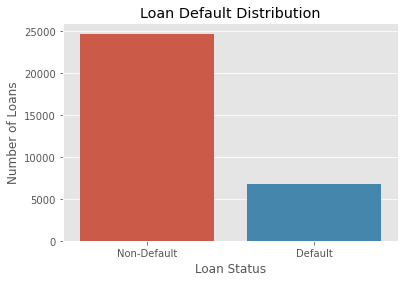

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="loan_status")

plt.title("Loan Default Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Loans")

plt.xticks([0,1],["Non-Default","Default"])

plt.show()

# Which home ownership type is most common?

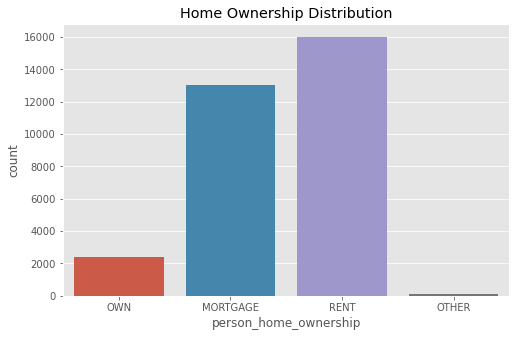

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="person_home_ownership")

plt.title("Home Ownership Distribution")

plt.show()

# What are borrowers using loans for?

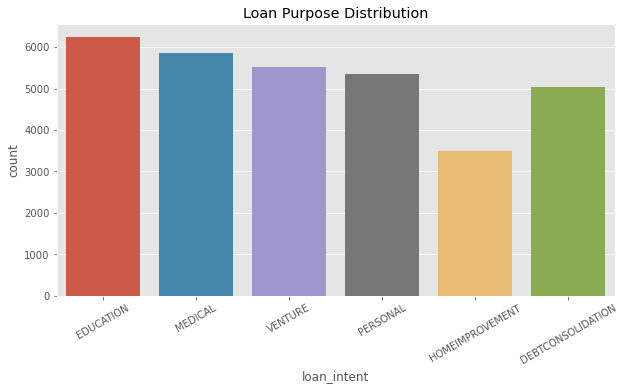

In [11]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="loan_intent")

plt.title("Loan Purpose Distribution")

plt.xticks(rotation=30)

plt.show()

# How are loans distributed across risk grades?

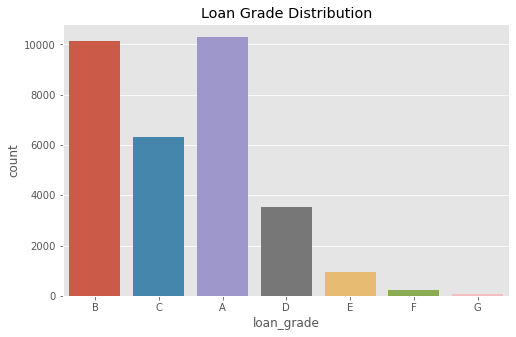

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="loan_grade")

plt.title("Loan Grade Distribution")

plt.show()

# Income distribution

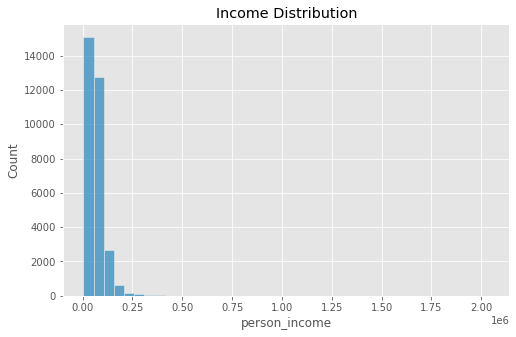

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["person_income"], bins=40)

plt.title("Income Distribution")

plt.show()

# Loan Amount distribution

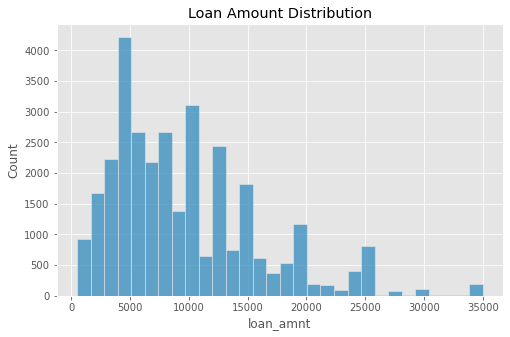

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["loan_amnt"], bins=30)

plt.title("Loan Amount Distribution")

plt.show()

# Interest rate distribution

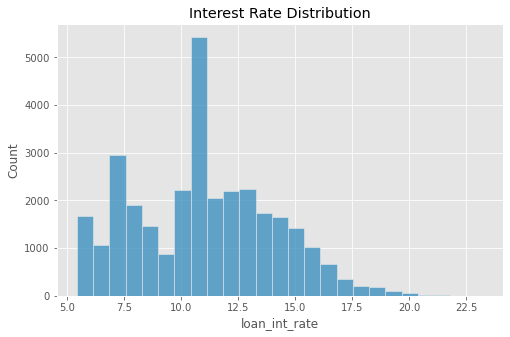

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["loan_int_rate"], bins=25)

plt.title("Interest Rate Distribution")

plt.show()

# Do lower credit grades default more often?

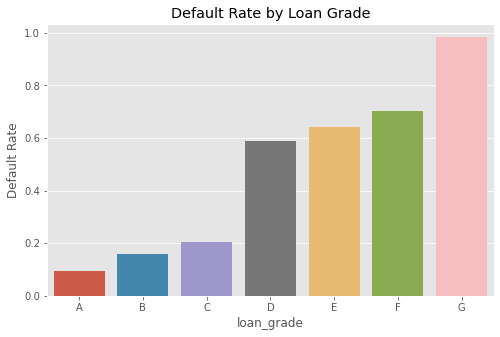

In [16]:
default_grade = df.groupby("loan_grade")["loan_status"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(data=default_grade,
            x="loan_grade",
            y="loan_status")

plt.title("Default Rate by Loan Grade")

plt.ylabel("Default Rate")

plt.show()

# Which loan purposes have the highest default rates?

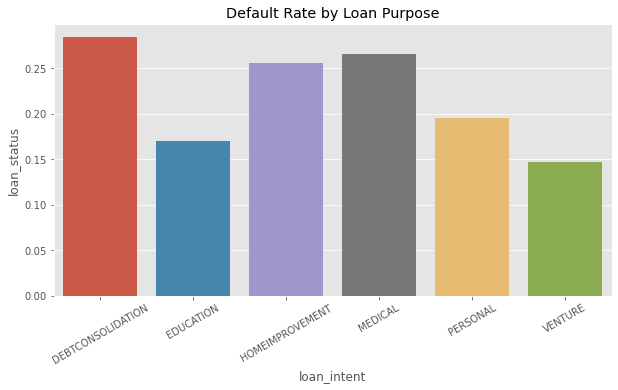

In [17]:
purpose_default = df.groupby("loan_intent")["loan_status"].mean().reset_index()

plt.figure(figsize=(10,5))

sns.barplot(data=purpose_default,
            x="loan_intent",
            y="loan_status")

plt.xticks(rotation=30)

plt.title("Default Rate by Loan Purpose")

plt.show()

# default rate by home ownership

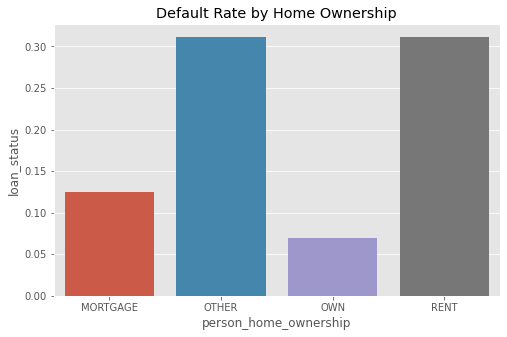

In [18]:
ownership_default = df.groupby("person_home_ownership")["loan_status"].mean().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(data=ownership_default,
            x="person_home_ownership",
            y="loan_status")

plt.title("Default Rate by Home Ownership")

plt.show()

# Age VS Default

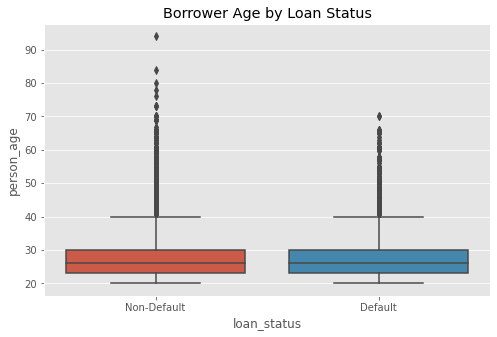

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="loan_status",
            y="person_age")

plt.xticks([0,1],["Non-Default","Default"])

plt.title("Borrower Age by Loan Status")

plt.show()

# income VS default

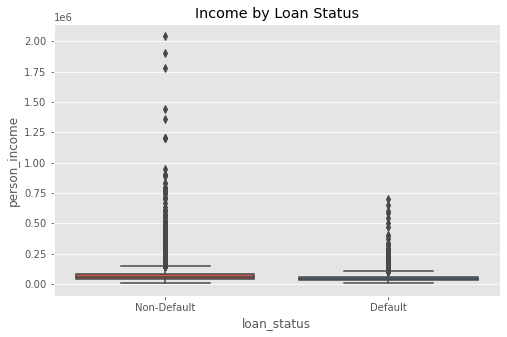

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="loan_status",
            y="person_income")

plt.xticks([0,1],["Non-Default","Default"])

plt.title("Income by Loan Status")

plt.show()

# Interest Rate VS Default

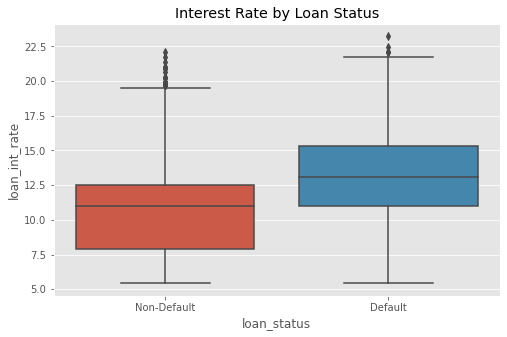

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df,
            x="loan_status",
            y="loan_int_rate")

plt.xticks([0,1],["Non-Default","Default"])

plt.title("Interest Rate by Loan Status")

plt.show()

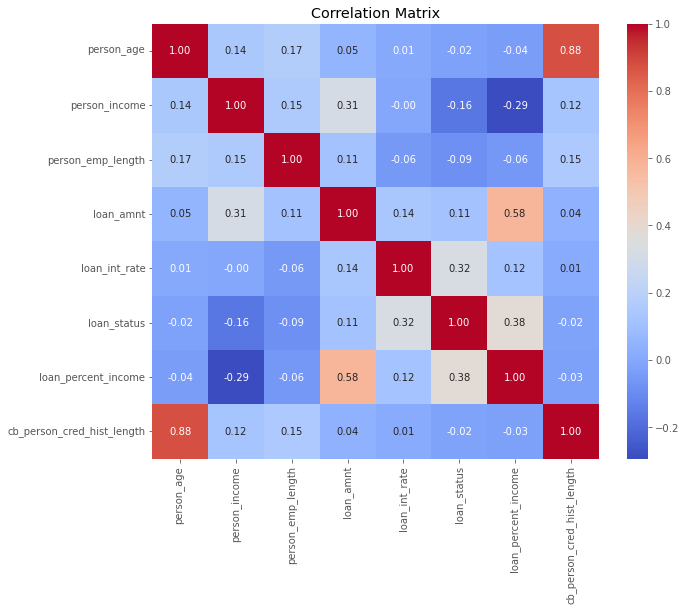

In [24]:
numeric_df = df.select_dtypes(include=["number"])

corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Matrix")
plt.show()

# EDA Summary

Key findings from the exploratory analysis include:

- The portfolio has a default rate of approximat21.59y XX%.
- Lower loan grades exhibit higher default rates.
- Interest rates are generally higher for defaulted loans.
- Loan purposes differ in their default behaviour.
- Income and loan amount distributions are right-skewed.
- Most borrowers fall within the younger adult age range.
- Correlation analysis suggests that interest rate and loan-to-income ratio are associated with default risk.

These insights will guide the feature engineering and predictive modelling stages of the project.